In [12]:
import numpy as np 
import pandas as pd 
import seaborn as sb 


Lendo o CSV


In [13]:
df_vendas = pd.read_csv("../../data/vendas_brasil_1.csv")


# Parte 1 NP Array

Criando NP array


In [14]:
npprecounit = np.array([df_vendas["preco_unitario"]])
npcustounit = np.array([df_vendas["custo_unitario"]])              
npquantidade = np.array([df_vendas["quantidade"]])
npdesconto = np.array([df_vendas["desconto_pct"]])
npreceitatot = np.array([df_vendas["receita_total"]])
npfrete = np.array([df_vendas["frete"]])


npprecounit,npcustounit,npquantidade,npdesconto,npreceitatot,npfrete

(array([[ 739.39,  187.48,   76.11, ...,   55.15,  197.09, 1057.41]],
       shape=(1, 37617)),
 array([[561.75, 135.15,  61.4 , ...,  36.94, 167.23, 870.69]],
       shape=(1, 37617)),
 array([[10,  5, 14, ...,  7,  7,  4]], shape=(1, 37617)),
 array([[ 5.2,  0.6,  0.7, ...,  0. , 10.9, 10. ]], shape=(1, 37617)),
 array([[6933.48,  930.28, 1058.5 , ...,  384.44, 1960.18, 3795.73]],
       shape=(1, 37617)),
 array([[ 8.68,   nan,  7.98, ..., 85.35, 30.99, 27.23]], shape=(1, 37617)))

# Cálculos

In [15]:
valor_bruto_venda = npprecounit*npquantidade
valor_desconto = valor_bruto_venda*npdesconto/100
valor_custo =  npcustounit*npquantidade
valor_lucro = valor_bruto_venda-valor_desconto-valor_custo

valor_bruto_venda,valor_desconto,valor_lucro,valor_custo

(array([[7393.9 ,  937.4 , 1065.54, ...,  386.05, 1379.63, 4229.64]],
       shape=(1, 37617)),
 array([[384.4828 ,   5.6244 ,   7.45878, ...,   0.     , 150.37967,
         422.964  ]], shape=(1, 37617)),
 array([[1391.9172 ,  256.0256 ,  198.48122, ...,  127.47   ,   58.64033,
          323.916  ]], shape=(1, 37617)),
 array([[5617.5 ,  675.75,  859.6 , ...,  258.58, 1170.61, 3482.76]],
       shape=(1, 37617)))

In [16]:
receita_media = np.mean(npreceitatot)
mask_acima_media = npreceitatot>receita_media
acima_media = npreceitatot[mask_acima_media]

mask_prejuizo = npreceitatot<valor_desconto+valor_custo
prejuizo = valor_lucro[mask_prejuizo]
#Não sabia se era em valor ou percentual, ent fiz os dois
desconto_medio_abs = np.mean(valor_desconto)
mask_desc_alto_abs = valor_desconto>desconto_medio_abs
desc_alto_abs = valor_desconto[mask_desc_alto_abs]

desconto_medio_per = np.mean(npdesconto)
mask_desc_alto_per = npdesconto>desconto_medio_per
desc_alto_per = valor_desconto[mask_desc_alto_per]

print(f"Receita acima da média:{np.sum(mask_acima_media==True)}")
print(f"Prejuízo :( :{np.sum(mask_prejuizo==True)}")
print(f"Desconto alto abs:{np.sum(mask_desc_alto_abs==True)}")
print(f"Desconto alto per:{np.sum(mask_desc_alto_per==True)}")





Receita acima da média:9236
Prejuízo :( :10266
Desconto alto abs:8321
Desconto alto per:17853


# Agregações

In [17]:
receita_media = receita_media
receita_maxima = np.max(npreceitatot)
receita_minima = np.min(npreceitatot)
lucromedio = np.mean(valor_lucro)
print(f"Receita média  :{receita_media}")
print(f"Receita máxima  :{receita_maxima}")
print(f"Receita mínima  :{receita_minima}")
print(f"Lucro médio  :{lucromedio}")


print(f"Prejuízo :( :{np.sum(mask_prejuizo==True)}")



Receita média  :1891.6881729005502
Receita máxima  :58430.28
Receita mínima  :3.7
Lucro médio  :342.0324771624532
Prejuízo :( :10266


# Parte 2: PANDAS

Exploração inicial

In [18]:
df_vendas.head()
df_vendas.info()
df_vendas.describe()
df_vendas.shape
df_vendas.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37617 entries, 0 to 37616
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   data_venda          37617 non-null  object 
 1   mes                 37617 non-null  int64  
 2   cidade              37617 non-null  object 
 3   canal_venda         37567 non-null  object 
 4   categoria           37617 non-null  object 
 5   produto             37617 non-null  object 
 6   vendedor            37577 non-null  object 
 7   fidelidade_cliente  37617 non-null  object 
 8   preco_unitario      37617 non-null  float64
 9   custo_unitario      37617 non-null  float64
 10  margem_pct          37535 non-null  float64
 11  quantidade          37617 non-null  int64  
 12  desconto_pct        37617 non-null  float64
 13  receita_total       37617 non-null  float64
 14  frete               35738 non-null  float64
 15  avaliacao_cliente   34662 non-null  float64
 16  praz

data_venda               0
mes                      0
cidade                   0
canal_venda             50
categoria                0
produto                  0
vendedor                40
fidelidade_cliente       0
preco_unitario           0
custo_unitario           0
margem_pct              82
quantidade               0
desconto_pct             0
receita_total            0
frete                 1879
avaliacao_cliente     2955
prazo_entrega_dias    1504
devolucao                0
entrega_no_prazo         0
alta_temporada           0
flag_outlier_preco       0
dtype: int64

1. Quantas linhas e colunas existem?

37616 linhas e 21 colunas

2. Existem dados faltantes?

Sim, principalmente nas colunas de frete, avaliacao_cliente e prazo_entrega_dias   
 
3. Quais colunas parecem numéricas?

preco_unitario , custo_unitario , margem_pct
quantidade , desconto_pct , receita_total , frete
prazo_entrega_dias

4. Quais colunas parecem categóricas?

data_venda , mes , cidade , canal_venda , categoria , produto

vendedor ,fidelidade_cliente , avaliacao_cliente

devolucao , entrega_no_prazo , alta_temporada , flag_outlier_preco


# Limpeza e Tratamento

In [19]:
df_vendas["data_venda"] = pd.to_datetime(df_vendas["data_venda"],  format="mixed")

In [20]:
#Verificando possiveis padronizações
print(df_vendas["canal_venda"].unique())


['App Mobile' 'Site Web' 'Loja Física' 'Marketplace' 'Televendas'
 'APP Mobile' 'site web' 'Site web' 'app mobile' 'SiteWeb' nan
 'Loja Fisica' 'App mobile' 'loja física' 'Loja fisica']


In [21]:
#Tirando o case sensitive, e os possiveis espaços errados nos finais
df_vendas['canal_venda'] = df_vendas['canal_venda'].str.strip().str.lower()
#Fazendo para um padrão 
dicionario_padronizacao = {
    'app mobile': 'App Mobile',
    'site web': 'Site Web',
    'siteweb': 'Site Web',
    'loja física': 'Loja Física',
    'loja fisica': 'Loja Física',
    'marketplace': 'Marketplace',
    'televendas': 'Televendas'
}
#replace pra só trocar o que achar
df_vendas['canal_venda'] = df_vendas['canal_venda'].replace(dicionario_padronizacao)
print(df_vendas["canal_venda"].unique())


['App Mobile' 'Site Web' 'Loja Física' 'Marketplace' 'Televendas' nan]


Tratando dados faltantes: margem_pct. Interpretei como (preco_unitario-custo_unitario)/preco_unitario

In [26]:

df_vendas.fillna({"margem_pct": (df_vendas["preco_unitario"]-df_vendas["custo_unitario"])/df_vendas["custo_unitario"]},inplace=True)

Criando novas colunas


In [ ]:
#Tabelas de lucro, ano e mês
df_vendas["lucro"] = (((df_vendas["preco_unitario"]-df_vendas["custo_unitario"])*df_vendas["quantidade"])*(1-df_vendas["desconto_pct"])-df_vendas["frete"])
df_vendas["ano"] = df_vendas["data_venda"].dt.year
df_vendas["mes"] = df_vendas["data_venda"].dt.month

Filtros

In [30]:
print(f"Vendas com receita acima de 500: \n{df_vendas[df_vendas['receita_total']>500]}")
print(f"Vendas com devolução: \n{df_vendas[df_vendas['devolucao'] == True]}")
print(f"Vendas que pertencem à categoria Eletrônicos: \n{df_vendas[df_vendas['categoria']=='Eletrônicos']}")

Vendas com receita acima de 500: 
      data_venda  mes          cidade  canal_venda    categoria  \
0     2022-04-13    4  Rio de Janeiro   App Mobile  Eletrônicos   
1     2023-03-12    3          Manaus     Site Web    Vestuário   
2     2022-09-28    9         Goiânia   App Mobile    Vestuário   
3     2022-04-17    4       Fortaleza     Site Web    Vestuário   
5     2023-12-02   12          Recife  Loja Física       Livros   
...          ...  ...             ...          ...          ...   
37609 2023-12-31   12  Belo Horizonte   App Mobile     Esportes   
37612 2023-12-31   12    Porto Alegre   App Mobile  Alimentação   
37613 2023-12-31   12        Salvador     Site Web  Alimentação   
37615 2023-12-31   12       São Paulo     Site Web     Esportes   
37616 2023-12-31   12       Fortaleza   Televendas  Eletrônicos   

                produto       vendedor fidelidade_cliente  preco_unitario  \
0              Notebook    Bruno Souza           Diamante          739.39   
1      

Agrupamentos com groupby


In [ ]:
#1 Agrupar receita total por categoria
df_vendas.groupby("categoria")["receita_total"].sum().sort_values(ascending=False)


categoria
Eletrônicos    45017479.88
Esportes       11567480.75
Vestuário       6780473.93
Livros          4462597.93
Alimentação     3331601.51
Name: receita_total, dtype: float64

In [ ]:
#2 Agrupar vendas totais por canal de venda
df_vendas.groupby("canal_venda").size().sort_values(ascending=False)

canal_venda
Site Web       11346
App Mobile     11258
Loja Física     7498
Marketplace     5604
Televendas      1861
dtype: int64

In [ ]:
#3 Agrupar receita total por cidade
df_vendas.groupby("cidade")["receita_total"].sum().sort_values(ascending=False)

cidade
Recife             7638412.70
Manaus             7435641.08
Fortaleza          7224144.20
Goiânia            7137063.48
Porto Alegre       7026847.56
Curitiba           6908794.29
Salvador           6850939.15
Belo Horizonte     6843262.46
Rio de Janeiro     6813063.15
São Paulo          6771119.98
salvador             37694.31
Goiânia              35476.13
Curtiba              31004.77
SP                   27222.85
B. Horizonte         25729.15
Slavador             25687.02
S. Paulo             25647.30
Rio de janeiro       24056.54
curitiba             24014.90
São paulo            23977.84
 Curitiba            21260.30
Porto Alegre         19252.05
Belo horizonte       19049.77
 Rio de Janeiro      16690.05
 Manaus              16450.02
 Fortaleza           13750.36
Recife               12876.68
Rio                  11249.71
 Recife              10952.41
 Belo Horizonte       9174.57
BH                    9002.65
Belo Horizonte        8529.01
Curitiba              8100.81
São

Merge


In [ ]:
#Criando a subtabela: verificar o que foi online e o que foi físico, e o que foi telecom
print(df_vendas["canal_venda"].unique())
tabela_tipo_venda = pd.DataFrame([
    ["App Mobile","Online"],
    ["Site Web","Online"],
    ["Marketplace","Online"],
    ["Televendas","Telecomunicação"],
    ["Loja Física", "Presencial"]
], columns=["canal_venda","tipo_venda"])


['App Mobile' 'Site Web' 'Loja Física' 'Marketplace' 'Televendas' nan]


In [ ]:
#Merge com o df original
df_vendas = df_vendas.merge(tabela_tipo_venda, on='canal_venda', how='left')



In [60]:
#Quantas vendas por tipo de venda

print(f"Vendas por tipo de venda: \n{df_vendas.groupby('tipo_venda')['receita_total'].count().sort_values(ascending=False)}")
#Receita vendas por tipo
print(f"Receita vendas por tipo de venda: \n{df_vendas.groupby('tipo_venda')['receita_total'].sum().sort_values(ascending=False)}")


Vendas por tipo de venda: 
tipo_venda
Online             28208
Presencial          7498
Telecomunicação     1861
Name: receita_total, dtype: int64
Receita vendas por tipo de venda: 
tipo_venda
Online             52800994.09
Presencial         14775508.06
Telecomunicação     3487189.72
Name: receita_total, dtype: float64


Dessa última análise, é legal notar que é relativamente proporcional a relação entre qtd de vendas e valor das vendas entre online ou presencial. Ou seja, não há preferência de meio para vendas mais caras.

Algo a se notar é que a margem pct não parecia consistente, mas só preenchi os valores, e não mexi nos "incorretos".

# Parte 3, gráficos e Seaborn


Gráfico de barras

In [89]:
import matplotlib.pyplot as plt
sb.set_theme(rc={'figure.figsize': (10, 6)})

#Ajustando o tamanho

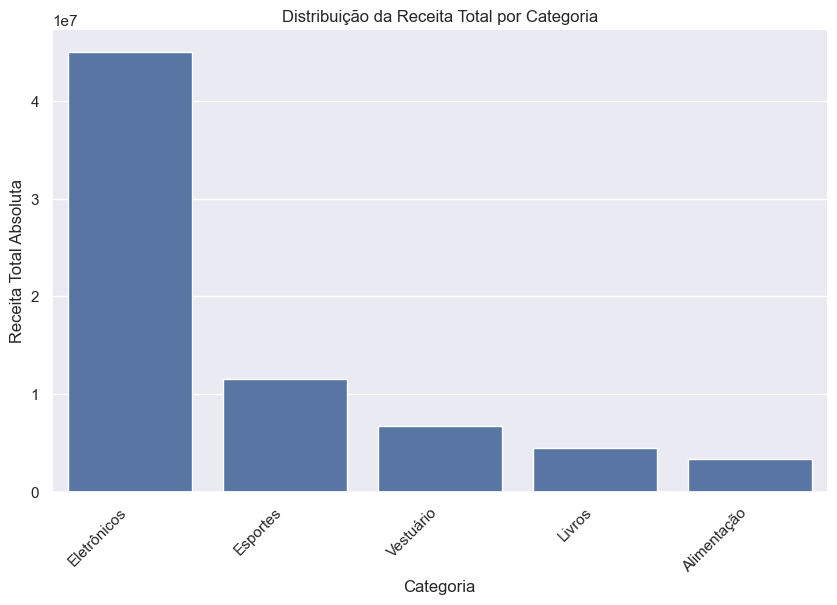

In [90]:
df_receita_categoria = df_vendas.groupby('categoria')['receita_total'].sum().reset_index()

df_receita_categoria = df_receita_categoria.sort_values(by='receita_total', ascending=False)


sb.barplot(
    data=df_receita_categoria,
    x='categoria',
    y='receita_total',
)

sb.despine() # Remoção das bordas 
plt.xlabel('Categoria')
plt.ylabel('Receita Total Absoluta')
plt.title('Distribuição da Receita Total por Categoria')

# 6. Rotação dos rótulos do eixo X (necessário caso os nomes das categorias sejam extensos)
plt.xticks(rotation=45, ha='right')

plt.show()

Demonstra claramente o setor de eletrônicos como sendo o mais comprado

Gráfico de linha

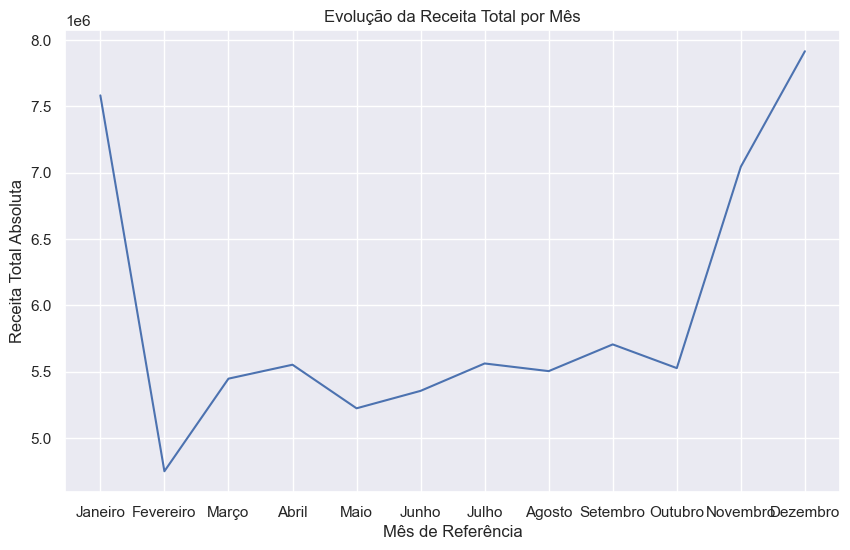

In [94]:
dicionario_meses = {
    1: 'Janeiro', 2: 'Fevereiro', 3: 'Março', 4: 'Abril', 
    5: 'Maio', 6: 'Junho', 7: 'Julho', 8: 'Agosto', 
    9: 'Setembro', 10: 'Outubro', 11: 'Novembro', 12: 'Dezembro'
}

receita_mes = df_vendas.groupby('mes')['receita_total'].sum().reset_index()
receita_mes = receita_mes.sort_values(by='mes', ascending=True)
receita_mes['mes_nome'] = receita_mes['mes'].map(dicionario_meses)


sb.lineplot(
    data=receita_mes, 
    x='mes_nome', 
    y='receita_total', 
    sort=False, 
)
plt.title('Evolução da Receita Total por Mês')
plt.xlabel('Mês de Referência')
plt.ylabel('Receita Total Absoluta')
plt.show()

Demonstra que os mêses de maior receita coincidem com as férias e período festivo.

Gráfico dispersão

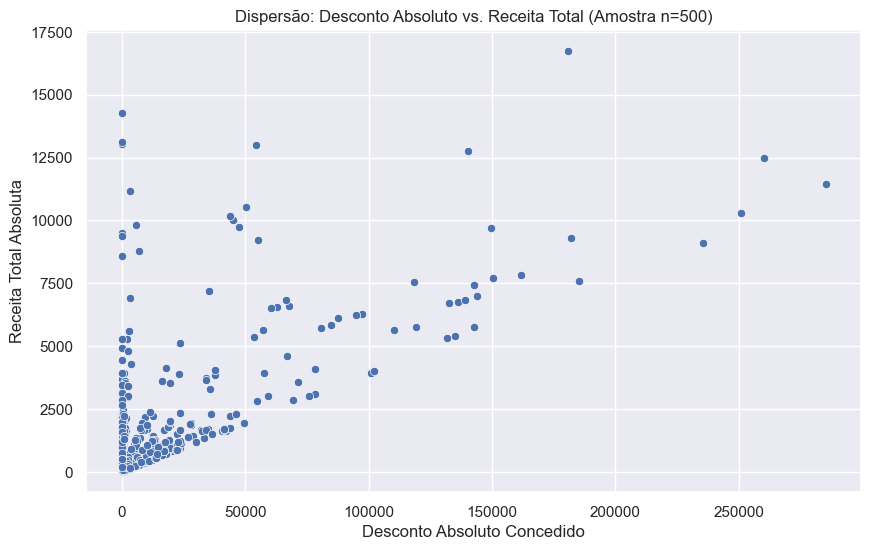

In [96]:
df_vendas['desconto_absoluto'] = (df_vendas['receita_total'] * df_vendas['desconto_pct'])

n_amostra = 500 
df_amostra = df_vendas.sample(n=n_amostra, random_state=42)

plt.figure(figsize=(10, 6))

sb.scatterplot(
    data=df_amostra,
    x='desconto_absoluto',
    y='receita_total', 
)

# 5. Demarcação textual rigorosa
plt.title('Dispersão: Desconto Absoluto vs. Receita Total (Amostra n=500)')
plt.xlabel('Desconto Absoluto Concedido')
plt.ylabel('Receita Total Absoluta')

# 6. Invocação do ciclo de exibição geométrica
plt.show()

Há uma grande concentração de descontos absolutos em 0, e geralmente não passa de 50% do valor.

Mapa de calor

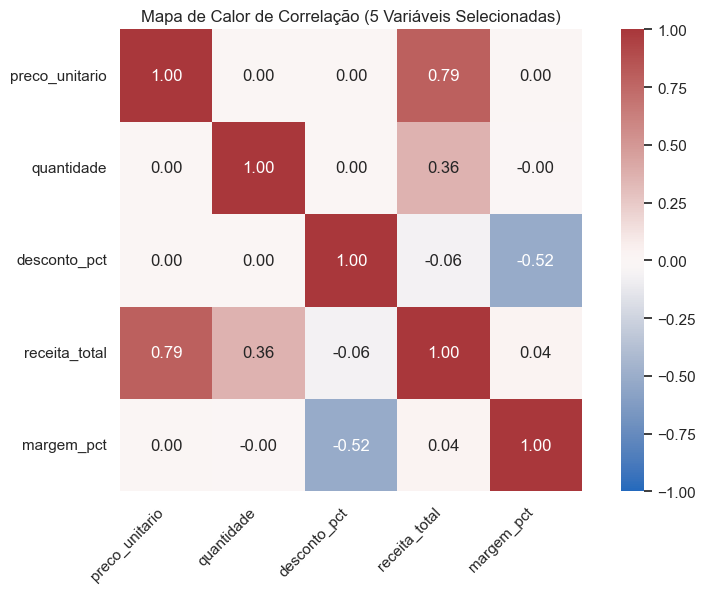

In [ ]:
colunas_selecionadas = [
    'preco_unitario', 
    'quantidade', 
    'desconto_pct', 
    'receita_total', 
    'margem_pct'
]

matriz_correlacao = df_vendas[colunas_selecionadas].corr()


sb.heatmap(
    data=matriz_correlacao,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    vmin=-1.0,
    vmax=1.0,
    center=0,
    square=True
)

# 5. Demarcação textual e finalização
plt.title('Mapa de Calor de Correlação (5 Variáveis Selecionadas)')


plt.show()

# Destaques do heatmap
O desconto percentual tem relação negativa com a margem, como esperado
A receita total tem relação positiva com o preço unitário e qtd, também esperado